# **This notebook shows how to calculate labor productivity using WBGT data.**

### **It corresponds to Figure 11 in the paper _High-resolution modeling of wet-bulb globe temperature reveals substantial heat risks among agricultural workers in Southern California_ by Parajuli et al. (2026) in _GeoHealth_.**

# Please download the following data to run this script:
# CEC labor data:
https://drive.google.com/file/d/1qaz8hLcVUyDNHpyxmhEZ-hc_2x57PPx7/view?usp=sharing

# WBGT data over the Imperial Valley (2020)

https://drive.google.com/file/d/1DtyoJssOt9BdU-5d5CBNIj_2wQIwz2tM/view?usp=sharing






In [ ]:
import pandas as pd

# Read the CSV file into a pandas DataFrame
farm_labor = pd.read_csv(r'/content/drive/MyDrive/Google_Drive_UTmail/SDSU/papers/wbgt_croptypes_exceedances/ces_2014-2024_monthly_20241115.csv')
farm_labor

,Area Type,Area Name,Year,Month,Date,Series Code,Industry Title,Seasonally Adjusted (Y/N),Current Employment,Benchmark
0,County,Alameda County,2014,January,01/1/2014,11000000,Total Farm,N,500,2023
1,County,Alameda County,2014,January,01/1/2014,60540000,"Professional, Scientific, and Technica...",N,63600,2023
2,County,Alameda County,2014,January,01/1/2014,65610000,Private Educational Services,N,15400,2023
3,County,Alameda County,2014,January,01/1/2014,65000000,Private Education and Health Services,N,110700,2023
4,County,Alameda County,2014,January,01/1/2014,60550000,Management of Companies and Enterprises,N,18400,2023
...,...,...,...,...,...,...,...,...,...,...
522836,State,California,2024,October,10/1/2024,65624400,Child Day Care Services,N,82200,2023
522837,State,California,2024,October,10/1/2024,65623900,Other Residential Care Facilities,N,12000,2023
522838,State,California,2024,October,10/1/2024,65623300,Comm Care Facilities for the Elderly,N,107000,2023
522839,State,California,2024,October,10/1/2024,70722300,Special Food Services,N,86300,2023


In [ ]:
df_2020 = farm_labor[(farm_labor['Year'] == 2020) & (farm_labor['Industry Title'] == 'Total Farm') & (farm_labor['Area Name'] == 'Imperial County')]
df_2020

,Area Type,Area Name,Year,Month,Date,Series Code,Industry Title,Seasonally Adjusted (Y/N),Current Employment,Benchmark
292403,County,Imperial County,2020,January,01/1/2020,11000000,Total Farm,N,10800,2023
296456,County,Imperial County,2020,February,02/1/2020,11000000,Total Farm,N,11500,2023
300512,County,Imperial County,2020,March,03/1/2020,11000000,Total Farm,N,10100,2023
304568,County,Imperial County,2020,April,04/1/2020,11000000,Total Farm,N,9500,2023
308624,County,Imperial County,2020,May,05/1/2020,11000000,Total Farm,N,12200,2023
312680,County,Imperial County,2020,June,06/1/2020,11000000,Total Farm,N,11100,2023
316736,County,Imperial County,2020,July,07/1/2020,11000000,Total Farm,N,9400,2023
320792,County,Imperial County,2020,August,08/1/2020,11000000,Total Farm,N,9200,2023
324848,County,Imperial County,2020,September,09/1/2020,11000000,Total Farm,N,9300,2023
328903,County,Imperial County,2020,October,10/1/2020,11000000,Total Farm,N,9300,2023


In [ ]:
df_rs = farm_labor[(farm_labor['Year'] == 2020) & (farm_labor['Industry Title'] == 'Total Farm') & (farm_labor['Area Name'] == 'Riverside County')]
df_rs

,Area Type,Area Name,Year,Month,Date,Series Code,Industry Title,Seasonally Adjusted (Y/N),Current Employment,Benchmark
293205,County,Riverside County,2020,January,01/1/2020,11000000,Total Farm,N,12700,2023
297255,County,Riverside County,2020,February,02/1/2020,11000000,Total Farm,N,11900,2023
301312,County,Riverside County,2020,March,03/1/2020,11000000,Total Farm,N,11800,2023
305375,County,Riverside County,2020,April,04/1/2020,11000000,Total Farm,N,10600,2023
309432,County,Riverside County,2020,May,05/1/2020,11000000,Total Farm,N,13000,2023
313487,County,Riverside County,2020,June,06/1/2020,11000000,Total Farm,N,14700,2023
317544,County,Riverside County,2020,July,07/1/2020,11000000,Total Farm,N,12900,2023
321598,County,Riverside County,2020,August,08/1/2020,11000000,Total Farm,N,9800,2023
325655,County,Riverside County,2020,September,09/1/2020,11000000,Total Farm,N,9800,2023
329710,County,Riverside County,2020,October,10/1/2020,11000000,Total Farm,N,11200,2023


In [ ]:
total_rs = df_rs['Current Employment'].sum()
total_iv = df_2020['Current Employment'].sum()
print(total_rs)
print(total_iv)
total_workers_rs_iv_2020 = total_rs + total_iv
print(total_workers_rs_iv_2020)

142000
124300
266300


In [ ]:
for value in df_2020['Current Employment']:
    print(value)

import datetime

# List of months

# List of target months
month_list = ["April", "May", "June", "July", "August", "September", "October"]

# Extract employment data for all matching months
employment_values = df_2020.loc[df_2020['Month'].isin(month_list), 'Current Employment'].values
employment_values

10800
11500
10100
9500
12200
11100
9400
9200
9300
9300
11100
10800


array([ 9500, 12200, 11100,  9400,  9200,  9300,  9300])

In [ ]:
# Load the array back
import numpy as np
data = np.load('/content/drive/MyDrive/Google_Drive_UTmail/SDSU/python_colab_data/wbgt_c_apr_oct.npz')
wbgt_c = data['wbgt_gcm_c']
wbgt_c[wbgt_c < -100] = np.nan;

# calculate productivity loss
wbgt_c +=3; # increase WBGT with clothing correction factor to get wbgt-eff
wbgt_c_iv = wbgt_c[:, 20:70, 106:140];
wbgt_c_iv_diurnal = np.reshape(wbgt_c_iv, (24, 214, 50, 34), order='F');

In [ ]:
# calculation of workability as per ISO

# calculate RAL and REL in degree celsius

import numpy as np

M = np.arange(100, 501, 10)
M.shape

RAL = 59.9 - 14.1 * np.log10(M)
REL = 56.7 - 11.5 * np.log10(M)
RAL.shape


RAL_180 = 59.9 - 14.1 * np.log10(180)
RAL_300 = 59.9 - 14.1 * np.log10(300)
RAL_415 = 59.9 - 14.1 * np.log10(415)

print('RAL 180 300 415', RAL_180, RAL_300, RAL_415)

REL_180 = 56.7 - 11.5 * np.log10(180)
REL_300 = 56.7 - 11.5 * np.log10(300)
REL_415 = 56.7 - 11.5 * np.log10(415)

print('REL 180 300 415', REL_180, REL_300, REL_415)


# calculate WBGTlim in rest conditions

WBGTlim_rest_RAL = 59.9 - 14.1 * np.log10(117) # 117 W is the metabolic rate at rest
WBGTlim_rest_REL = 56.7 - 11.5 * np.log10(117) # 117 W is the metabolic rate at rest

print('WBGTlim_rest_RAL', WBGTlim_rest_RAL)
print('WBGTlim_rest_REL', WBGTlim_rest_REL)

# calculate workability_ISO

lab_cap_RAL_180 = np.maximum(0, np.minimum(1, (WBGTlim_rest_RAL-wbgt_c_iv_diurnal)/(WBGTlim_rest_RAL-RAL_180)))
lab_cap_RAL_300 = np.maximum(0, np.minimum(1, (WBGTlim_rest_RAL-wbgt_c_iv_diurnal)/(WBGTlim_rest_RAL-RAL_300)))
lab_cap_RAL_415 = np.maximum(0, np.minimum(1, (WBGTlim_rest_RAL-wbgt_c_iv_diurnal)/(WBGTlim_rest_RAL-RAL_415)))

lab_cap_REL_180 = np.maximum(0, np.minimum(1, (WBGTlim_rest_REL-wbgt_c_iv_diurnal)/(WBGTlim_rest_REL-REL_180)))
lab_cap_REL_300 = np.maximum(0, np.minimum(1, (WBGTlim_rest_REL-wbgt_c_iv_diurnal)/(WBGTlim_rest_REL-REL_300)))
lab_cap_REL_415 = np.maximum(0, np.minimum(1, (WBGTlim_rest_REL-wbgt_c_iv_diurnal)/(WBGTlim_rest_REL-REL_415)))


print(lab_cap_RAL_180.shape)
print(np.nanmin(lab_cap_RAL_180.flatten()))
print(np.nanmax(lab_cap_RAL_180.flatten()))
print(np.nanmean(lab_cap_RAL_180.flatten()))


RAL 180 300 415 28.100657678043383 24.97259030845276 22.985521836359496
REL 180 300 415 30.764366191311982 28.213105570723883 26.59244688781094
WBGTlim_rest_RAL 30.73857934937912
WBGTlim_rest_REL 32.91586258991914
(24, 214, 50, 34)
0.0
1.0
0.7482416990138844


In [ ]:

# Find WBGT values where lab_cap_RAL_180 is 0
RAL_zero_values = wbgt_c_iv_diurnal[lab_cap_RAL_180 == 0]
print(np.min(RAL_zero_values))
REL_zero_values = wbgt_c_iv_diurnal[lab_cap_REL_180 == 0]
print(np.min(REL_zero_values))

diff_zero = np.min(REL_zero_values)-np.min(RAL_zero_values)
print('diff zero', diff_zero)

RAL_100_values = wbgt_c_iv_diurnal[lab_cap_RAL_180 == 1.0]
print(np.max(RAL_100_values))
REL_100_values = wbgt_c_iv_diurnal[lab_cap_REL_180 == 1.0]
print(np.max(REL_100_values))

diff_100 = np.max(REL_100_values)-np.max(RAL_100_values)
print('diff 100 ', diff_100)

# average diff
av_diff = (diff_zero+diff_100)/2
print('av diff', av_diff);

30.738579917309607
32.91586550236201
diff zero 2.1772855850524024
28.10065235197777
30.764364693206744
diff 100  2.6637123412289725
av diff 2.4204989631406875


In [ ]:
# calculate workability based on Brode's paper (second method) based on Kjellstrom's data
# Bröde, P., Fiala, D., Lemke, B. et al.
# Estimated work ability in warm outdoor environments depends on the chosen heat stress assessment metric.
# Int J Biometeorol 62, 331–345 (2018). https://doi.org/10.1007/s00484-017-1346-9

a1 = 34.64; a2 = 22.72;
b1 = 32.93; b2 = 17.81;
c1 = 30.94; c2 = 16.64;
workability_REL_180 = 0.1 + 0.9/(1 + (wbgt_c_iv_diurnal/a1)**a2)
workability_REL_300 = 0.1 + 0.9/(1 + (wbgt_c_iv_diurnal/b1)**b2)
workability_REL_415 = 0.1 + 0.9/(1 + (wbgt_c_iv_diurnal/c1)**c2)

wbgt_c_iv_diurnal_RAL = wbgt_c_iv_diurnal+av_diff; # for RAL WBGT is consistenly lower

workability_RAL_180 = 0.1 + 0.9/(1 + (wbgt_c_iv_diurnal_RAL/a1)**a2)
workability_RAL_300 = 0.1 + 0.9/(1 + (wbgt_c_iv_diurnal_RAL/b1)**b2)
workability_RAL_415 = 0.1 + 0.9/(1 + (wbgt_c_iv_diurnal_RAL/c1)**c2)

print(np.nanmean(workability_RAL_180.flatten()))
print(np.nanmean(workability_REL_180.flatten()))


0.8794870655858122
0.9448683993156369


In [ ]:
# create arrays for week-hour plot

workability_REL_180 = 1.0-workability_REL_180;  # convert to loss of productivity
workability_REL_300 = 1.0-workability_REL_300;
workability_REL_415 = 1.0-workability_REL_415;

workability_RAL_180 = 1.0-workability_RAL_180;
workability_RAL_300 = 1.0-workability_RAL_300;
workability_RAL_415 = 1.0-workability_RAL_415;


workability_REL_180_mean = np.nanmean(workability_REL_180, axis=(2, 3))*100
workability_REL_300_mean = np.nanmean(workability_REL_300, axis=(2, 3))*100
workability_REL_415_mean = np.nanmean(workability_REL_415, axis=(2, 3))*100

workability_RAL_180_mean = np.nanmean(workability_RAL_180, axis=(2, 3))*100
workability_RAL_300_mean = np.nanmean(workability_RAL_300, axis=(2, 3))*100
workability_RAL_415_mean = np.nanmean(workability_RAL_415, axis=(2, 3))*100



<ipython-input-10-a03db80d56a5>:12: RuntimeWarning: Mean of empty slice
  workability_REL_180_mean = np.nanmean(workability_REL_180, axis=(2, 3))*100
<ipython-input-10-a03db80d56a5>:13: RuntimeWarning: Mean of empty slice
  workability_REL_300_mean = np.nanmean(workability_REL_300, axis=(2, 3))*100
<ipython-input-10-a03db80d56a5>:14: RuntimeWarning: Mean of empty slice
  workability_REL_415_mean = np.nanmean(workability_REL_415, axis=(2, 3))*100
<ipython-input-10-a03db80d56a5>:16: RuntimeWarning: Mean of empty slice
  workability_RAL_180_mean = np.nanmean(workability_RAL_180, axis=(2, 3))*100
<ipython-input-10-a03db80d56a5>:17: RuntimeWarning: Mean of empty slice
  workability_RAL_300_mean = np.nanmean(workability_RAL_300, axis=(2, 3))*100
<ipython-input-10-a03db80d56a5>:18: RuntimeWarning: Mean of empty slice
  workability_RAL_415_mean = np.nanmean(workability_RAL_415, axis=(2, 3))*100


In [ ]:
# calculate average productivity for each month

# Month labels
short_months = ["Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct"]

# calculate average productivity for 9am-5pm work shift

lab_prod_new_REL_apr = workability_REL_300[9:17, 0:30, :, :];
lab_prod_new_REL_may = workability_REL_300[9:17, 30:61, :, :];
lab_prod_new_REL_jun = workability_REL_300[9:17, 61:91, :, :];
lab_prod_new_REL_jul = workability_REL_300[9:17, 91:122, :, :];
lab_prod_new_REL_aug = workability_REL_300[9:17, 122:153, :, :];
lab_prod_new_REL_sep = workability_REL_300[9:17, 153:183, :, :];
lab_prod_new_REL_oct = workability_REL_300[9:17, 183:214, :, :];

lab_prod_new_REL_apr_av = np.nanmean(lab_prod_new_REL_apr.flatten());
lab_prod_new_REL_may_av = np.nanmean(lab_prod_new_REL_may.flatten());
lab_prod_new_REL_jun_av = np.nanmean(lab_prod_new_REL_jun.flatten());
lab_prod_new_REL_jul_av = np.nanmean(lab_prod_new_REL_jul.flatten());
lab_prod_new_REL_aug_av = np.nanmean(lab_prod_new_REL_aug.flatten());
lab_prod_new_REL_sep_av = np.nanmean(lab_prod_new_REL_sep.flatten());
lab_prod_new_REL_oct_av = np.nanmean(lab_prod_new_REL_oct.flatten());


# All data in a single list
data_lab_prod_new_REL = [lab_prod_new_REL_apr_av, lab_prod_new_REL_may_av, lab_prod_new_REL_jun_av, lab_prod_new_REL_jul_av, lab_prod_new_REL_aug_av, lab_prod_new_REL_sep_av, lab_prod_new_REL_oct_av]
data_lab_prod_new_REL = np.array(data_lab_prod_new_REL) * 100

# calculate average productivity for 4am–12pm work shift

lab_prod_new_REL_apr_4am = workability_REL_300[4:12, 0:30, :, :]
lab_prod_new_REL_may_4am = workability_REL_300[4:12, 30:61, :, :]
lab_prod_new_REL_jun_4am = workability_REL_300[4:12, 61:91, :, :]
lab_prod_new_REL_jul_4am = workability_REL_300[4:12, 91:122, :, :]
lab_prod_new_REL_aug_4am = workability_REL_300[4:12, 122:153, :, :]
lab_prod_new_REL_sep_4am = workability_REL_300[4:12, 153:183, :, :]
lab_prod_new_REL_oct_4am = workability_REL_300[4:12, 183:214, :, :]

lab_prod_new_REL_apr_av_4am = np.nanmean(lab_prod_new_REL_apr_4am.flatten())
lab_prod_new_REL_may_av_4am = np.nanmean(lab_prod_new_REL_may_4am.flatten())
lab_prod_new_REL_jun_av_4am = np.nanmean(lab_prod_new_REL_jun_4am.flatten())
lab_prod_new_REL_jul_av_4am = np.nanmean(lab_prod_new_REL_jul_4am.flatten())
lab_prod_new_REL_aug_av_4am = np.nanmean(lab_prod_new_REL_aug_4am.flatten())
lab_prod_new_REL_sep_av_4am = np.nanmean(lab_prod_new_REL_sep_4am.flatten())
lab_prod_new_REL_oct_av_4am = np.nanmean(lab_prod_new_REL_oct_4am.flatten())

# All data in a single list
data_lab_prod_new_REL_4am = [
    lab_prod_new_REL_apr_av_4am,
    lab_prod_new_REL_may_av_4am,
    lab_prod_new_REL_jun_av_4am,
    lab_prod_new_REL_jul_av_4am,
    lab_prod_new_REL_aug_av_4am,
    lab_prod_new_REL_sep_av_4am,
    lab_prod_new_REL_oct_av_4am
]
data_lab_prod_new_REL_4am = np.array(data_lab_prod_new_REL_4am) * 100

# calculate average productivity for 4pm–12am (midnight) work shift
lab_prod_new_REL_apr_4pm = workability_REL_300[np.r_[16:24, 0], 0:30, :, :]
lab_prod_new_REL_may_4pm = workability_REL_300[np.r_[16:24, 0], 30:61, :, :]
lab_prod_new_REL_jun_4pm = workability_REL_300[np.r_[16:24, 0], 61:91, :, :]
lab_prod_new_REL_jul_4pm = workability_REL_300[np.r_[16:24, 0], 91:122, :, :]
lab_prod_new_REL_aug_4pm = workability_REL_300[np.r_[16:24, 0], 122:153, :, :]
lab_prod_new_REL_sep_4pm = workability_REL_300[np.r_[16:24, 0], 153:183, :, :]
lab_prod_new_REL_oct_4pm = workability_REL_300[np.r_[16:24, 0], 183:214, :, :]

# Calculate average productivity for each month
lab_prod_new_REL_apr_av_4pm = np.nanmean(lab_prod_new_REL_apr_4pm)
lab_prod_new_REL_may_av_4pm = np.nanmean(lab_prod_new_REL_may_4pm)
lab_prod_new_REL_jun_av_4pm = np.nanmean(lab_prod_new_REL_jun_4pm)
lab_prod_new_REL_jul_av_4pm = np.nanmean(lab_prod_new_REL_jul_4pm)
lab_prod_new_REL_aug_av_4pm = np.nanmean(lab_prod_new_REL_aug_4pm)
lab_prod_new_REL_sep_av_4pm = np.nanmean(lab_prod_new_REL_sep_4pm)
lab_prod_new_REL_oct_av_4pm = np.nanmean(lab_prod_new_REL_oct_4pm)

# Combine into final array and convert to percentage
data_lab_prod_new_REL_4pm = np.array([
    lab_prod_new_REL_apr_av_4pm,
    lab_prod_new_REL_may_av_4pm,
    lab_prod_new_REL_jun_av_4pm,
    lab_prod_new_REL_jul_av_4pm,
    lab_prod_new_REL_aug_av_4pm,
    lab_prod_new_REL_sep_av_4pm,
    lab_prod_new_REL_oct_av_4pm
]) * 100



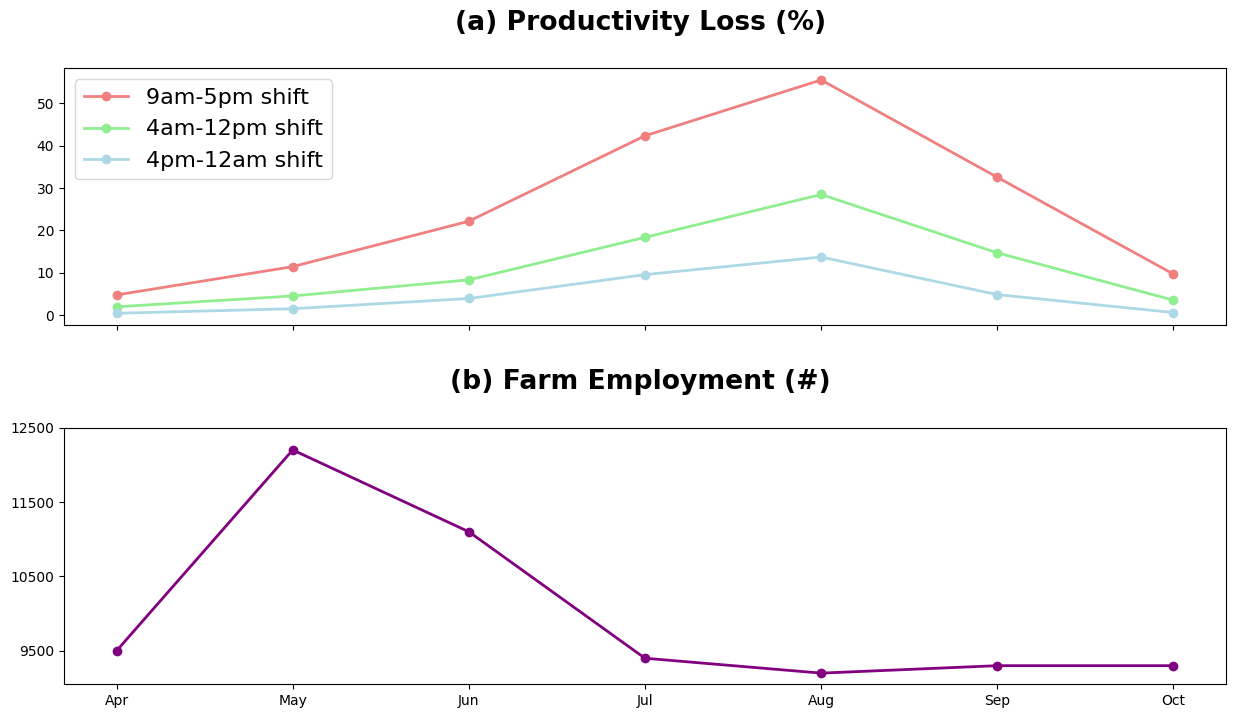

In [ ]:
# plot lower and upper bound time series, based on Brode/Kjellstrom curves

import matplotlib.pyplot as plt
import numpy as np


# Create subplots (2 rows x 1 column)
fig, axes = plt.subplots(2, 1, figsize=(15, 8))
plt.subplots_adjust(wspace=0.1, hspace=0.4)  # Adjust the width space between subplots


plt.rcParams.update({'font.size': 16})

# Plot on the first subplot (Labor Productivity)
axes[0].plot(short_months, data_lab_prod_new_REL, marker='o', color= 'lightcoral', linewidth=2, label='9am-5pm shift')
axes[0].plot(short_months, data_lab_prod_new_REL_4am, marker='o', color= 'lightgreen', linewidth=2, label='4am-12pm shift')
axes[0].plot(short_months, data_lab_prod_new_REL_4pm, marker='o', color= 'lightblue', linewidth=2, label='4pm-12am shift')

axes[0].set_title('(a) Productivity Loss (%) \n', fontweight='bold')
axes[0].set_xticklabels([])  # Hide x-axis labels
axes[0].legend(loc='upper left')
axes[0].set_yticks([0, 10, 20, 30, 40, 50])  # Define tick positions

# Plot on the second subplot (# of Farm Employment)
axes[1].plot(short_months, employment_values, marker='o', color='purple', linewidth=2)
axes[1].set_title('(b) Farm Employment (#) \n', fontweight='bold')
axes[1].set_yticks([9500, 10500, 11500, 12500])  # Define tick positions

# Save the figure
#plt.savefig('/content/drive/MyDrive/Google_Drive_UTmail/SDSU/papers/wbgt_croptypes_exceedances/Figures/productivity_comparisons_shift.png', bbox_inches='tight', dpi=400)

plt.show()
